In [2]:
# Cargamos librerías
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import xarray as xr
# # import cartopy.crs as ccrs

import os
import glob
# from datetime import datetime, timedelta
# import pandas as pd
# import geopandas as gpd


# import shutil

# import ast
from collections import Counter
# import intake

import json
# from pathlib import Path
# # import mlcast_datasets

# from pyproj import CRS, Transformer
# import tempfile
# import fiona

import random

# import re
# import rasterio
# from rasterio.merge import merge
# from rasterio.transform import Affine
# from rasterio.windows import from_bounds
# from scipy.ndimage import distance_transform_edt
# from rasterio.features import rasterize
# from rasterio.enums import Resampling
# from rasterio.warp import reproject
# from rasterio.transform import from_bounds

# from whitebox import WhiteboxTools

# from shapely.geometry import box

# from scipy.stats import mannwhitneyu
# from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# from PIL import Image

from joblib import Parallel, delayed
import string
import numpy as np


import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F

import time




Función para dividir el dataset en conjunto de train, test y validation, garantizando que la proporción de patches con y sin deslizamiento se mantiene en todos los conjuntos. 

In [5]:
def patch_has_landslide(patch_file):
    """
    Devuelve:
    - patch_id
    - label_patch: 1 si MASK contiene algún píxel de deslizamiento, 0 si no
    """
    patch_id = os.path.basename(patch_file)

    ds = xr.open_dataset(patch_file)
    mask = ds["MASK"].values
    ds.close()

    label_patch = int(np.nanmax(mask) > 0)

    return patch_id, label_patch


def create_stratified_split(
    patches_dir,
    output_path,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    seed=42,
    n_jobs=-1
):
    """
    Crea split train/val/test estratificado por presencia de deslizamiento.
    """

    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
        "Los ratios deben sumar 1."

    patch_files = sorted(glob.glob(os.path.join(patches_dir, "*.nc")))

    print(f"Total patches encontrados: {len(patch_files)}")

    # ---------- LEER LABEL POR PATCH EN PARALELO ----------
    results = Parallel(n_jobs=n_jobs)(
        delayed(patch_has_landslide)(patch_file)
        for patch_file in patch_files
    )

    patch_ids = np.array([r[0] for r in results])
    labels = np.array([r[1] for r in results])

    print("\nDistribución global:")
    print(f" - Con deslizamiento: {np.sum(labels == 1)}")
    print(f" - Sin deslizamiento: {np.sum(labels == 0)}")
    print(f" - Proporción positivos: {np.mean(labels):.3f}")

    # ---------- PRIMER SPLIT: TRAIN vs TEMP ----------
    temp_ratio = val_ratio + test_ratio

    train_ids, temp_ids, y_train, y_temp = train_test_split(
        patch_ids,
        labels,
        test_size=temp_ratio,
        random_state=seed,
        stratify=labels
    )

    # ---------- SEGUNDO SPLIT: VAL vs TEST ----------
    relative_test_ratio = test_ratio / temp_ratio

    val_ids, test_ids, y_val, y_test = train_test_split(
        temp_ids,
        y_temp,
        test_size=relative_test_ratio,
        random_state=seed,
        stratify=y_temp
    )

    split_dict = {
        "train": train_ids.tolist(),
        "val": val_ids.tolist(),
        "test": test_ids.tolist()
    }

    # ---------- GUARDAR ----------
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(split_dict, f, indent=2)

    # ---------- RESUMEN ----------
    def print_split_stats(name, ids, y):
        print(f"\n{name}:")
        print(f" - Total: {len(ids)}")
        print(f" - Con deslizamiento: {np.sum(y == 1)}")
        print(f" - Sin deslizamiento: {np.sum(y == 0)}")
        print(f" - Proporción positivos: {np.mean(y):.3f}")

    print_split_stats("TRAIN", train_ids, y_train)
    print_split_stats("VAL", val_ids, y_val)
    print_split_stats("TEST", test_ids, y_test)

    print(f"\nSplit guardado en: {output_path}")

    return split_dict

In [4]:
file_patch = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files\Sen2\italy_s2_250_enriched.nc"

patch_has_landslide(file_patch)

('italy_s2_250_enriched.nc', 0)

In [5]:
patches_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files\asc"
output_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split.json"
create_stratified_split(
    patches_dir,
    output_path,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    seed=42,
    n_jobs=-1
)

Total patches encontrados: 835

Distribución global:
 - Con deslizamiento: 481
 - Sin deslizamiento: 354
 - Proporción positivos: 0.576

TRAIN:
 - Total: 668
 - Con deslizamiento: 385
 - Sin deslizamiento: 283
 - Proporción positivos: 0.576

VAL:
 - Total: 83
 - Con deslizamiento: 48
 - Sin deslizamiento: 35
 - Proporción positivos: 0.578

TEST:
 - Total: 84
 - Con deslizamiento: 48
 - Sin deslizamiento: 36
 - Proporción positivos: 0.571

Split guardado en: C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split.json


{'train': ['italy_s1asc_3089_enriched.nc',
  'italy_s1asc_3355_enriched.nc',
  'italy_s1asc_3509_enriched.nc',
  'italy_s1asc_3124_enriched.nc',
  'italy_s1asc_2527_enriched.nc',
  'italy_s1asc_3004_enriched.nc',
  'italy_s1asc_3088_enriched.nc',
  'italy_s1asc_2550_enriched.nc',
  'italy_s1asc_2687_enriched.nc',
  'italy_s1asc_322_enriched.nc',
  'italy_s1asc_2728_enriched.nc',
  'italy_s1asc_2611_enriched.nc',
  'italy_s1asc_2934_enriched.nc',
  'italy_s1asc_3599_enriched.nc',
  'italy_s1asc_2876_enriched.nc',
  'italy_s1asc_2985_enriched.nc',
  'italy_s1asc_3313_enriched.nc',
  'italy_s1asc_3293_enriched.nc',
  'italy_s1asc_2669_enriched.nc',
  'italy_s1asc_2622_enriched.nc',
  'italy_s1asc_2667_enriched.nc',
  'italy_s1asc_2641_enriched.nc',
  'italy_s1asc_3659_enriched.nc',
  'italy_s1asc_2981_enriched.nc',
  'italy_s1asc_3187_enriched.nc',
  'italy_s1asc_3603_enriched.nc',
  'italy_s1asc_2783_enriched.nc',
  'italy_s1asc_3371_enriched.nc',
  'italy_s1asc_3440_enriched.nc',
  'ita

In [7]:

# Vemos si tenemos GPU disponible ...
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print("Usando dispositivo: CUDA 🚀")
else:
    print("Usando dispositivo: CPU 😞")

# Dataset que vamos a utilizar.
DATASET= "dataset_conversational.txt"

Usando dispositivo: CUDA 🚀


In [4]:
class LandslideDataset(Dataset):
    def __init__(self, patches_dir, patch_ids, dynamic_vars, static_vars, mean=None, std=None):
        self.patches_dir = patches_dir
        self.patch_ids = patch_ids
        self.dynamic_vars = dynamic_vars
        self.static_vars = static_vars
        self.mean = mean
        self.std = std
    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, idx):
        patch_id = self.patch_ids[idx]
        path = os.path.join(self.patches_dir, patch_id)

        ds = xr.open_dataset(path)

        # ---------- DINÁMICAS ----------
        dyn_list = []
        for var in self.dynamic_vars:
            arr = ds[var].values.astype(np.float32)  # (time, H, W)
            dyn_list.append(arr)

        # ---------- ESTÁTICAS ----------
        static_list = []
        for var in self.static_vars:
            arr = ds[var].values.astype(np.float32)

            if "time" in ds[var].dims:
                arr = arr[0]  # quitar dimensión time

            # repetir en el tiempo
            time_len = dyn_list[0].shape[0]
            arr = np.repeat(arr[None, :, :], time_len, axis=0)

            static_list.append(arr)

        # ---------- COMBINAR ----------
        all_vars = dyn_list + static_list  # lista de (time, H, W)

        # (channels, time, H, W)
        x = np.stack(all_vars, axis=0)

        # ---------- MASK ----------
        mask = ds["MASK"].values

        if "time" in ds["MASK"].dims:
            mask = mask[0]

        y = mask.astype(np.int64)  # para CrossEntropy

        ds.close()

        # convertir a tensor
        x = torch.from_numpy(x)  # float32
        y = torch.from_numpy(y)

        # ---------- NORMALIZACIÓN ----------
        if self.mean is not None and self.std is not None:
            x = (x - self.mean[:, None, None, None]) / (self.std[:, None, None, None] + 1e-6)

        return x, y

In [3]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.backends.cudnn.enabled)

2.7.1+cu118
True
11.8
True


In [4]:
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

1
NVIDIA GeForce RTX 2060


In [5]:
# Obtenemos los ids de los patches para el split de entrenamiento que están en el archivo split.json
output_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split.json"
with open(output_path, "r", encoding="utf-8") as f:
    split = json.load(f)
patches_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files\asc"
dynamic_vars = ["VV","VH", "prec7", "prec20", "max2d_7"]
static_vars = ["DEM", "slope", "aspect_sin", "aspect_cos", "profile_curvature", "area_drainage", "ls", "spi", "twi", "distance_to_drainage", "lithology_class"]


train_dataset = LandslideDataset(
    patches_dir,
    split["train"],
    dynamic_vars,
    static_vars
)

x, y = train_dataset[0]

print(x.shape)  # esperado: (channels, time, 128, 128)
print(y.shape)  # esperado: (128, 128)

torch.Size([16, 8, 128, 128])
torch.Size([128, 128])


In [10]:
x, y = train_dataset[0]

print(x.mean(), x.std())

tensor(721.9541) tensor(14121.8320)


Hay que aplicar normalización

In [18]:
def compute_mean_std(dataset, max_samples=None):
    """
    Calcula mean y std por canal usando solo TRAIN
    """
    sum_ = None
    sum_sq = None
    n_pixels = 0

    n = len(dataset)
    if max_samples:
        n = min(n, max_samples)

    for i in tqdm(range(n)):
        x, _ = dataset[i]  # (C, T, H, W)

        x = x.view(x.shape[0], -1)  # (C, T*H*W)

        if sum_ is None:
            sum_ = x.sum(dim=1)
            sum_sq = (x ** 2).sum(dim=1)
        else:
            sum_ += x.sum(dim=1)
            sum_sq += (x ** 2).sum(dim=1)

        n_pixels += x.shape[1]

    mean = sum_ / n_pixels
    std = torch.sqrt(sum_sq / n_pixels - mean ** 2)

    return mean, std

In [7]:
mean, std = compute_mean_std(train_dataset, max_samples=100)

print(mean.shape)  # (C,)
print(std.shape)

 23%|██▎       | 23/100 [01:13<04:07,  3.22s/it]


KeyboardInterrupt: 

Redefinimos train dataset con la normalización en la clase LandslideDataset

In [8]:
# Obtenemos los ids de los patches para el split de entrenamiento que están en el archivo split.json
output_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split.json"
with open(output_path, "r", encoding="utf-8") as f:
    split = json.load(f)
patches_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files\asc"
dynamic_vars = ["VV","VH", "prec7", "prec20", "max2d_7"]
static_vars = ["DEM", "slope", "aspect_sin", "aspect_cos", "profile_curvature", "area_drainage", "ls", "spi", "twi", "distance_to_drainage", "lithology_class"]


train_dataset_raw = LandslideDataset(
    patches_dir,
    split["train"],
    dynamic_vars,
    static_vars
)


In [11]:
mean, std = compute_mean_std(train_dataset_raw, max_samples=100)


100%|██████████| 100/100 [04:27<00:00,  2.68s/it]


In [13]:
print(mean)

tensor([-8.9904e+00, -1.5245e+01,  3.9258e+02,  7.4544e+02,  3.1974e+02,
         5.8875e-03,  3.8816e+02,  1.5651e+01, -3.6811e-02,  1.2341e-01,
        -1.0071e-04,  8.7210e+04,  1.0095e+01,  2.4936e+04,  9.0327e+00,
         1.8893e+02,  8.1041e+00])


In [14]:
train_dataset = LandslideDataset(
    patches_dir,
    split["train"],
    dynamic_vars,
    static_vars, mean=mean, std=std
)

val_dataset = LandslideDataset(
    patches_dir=patches_dir,
    patch_ids=split["val"],
    dynamic_vars=dynamic_vars,
    static_vars=static_vars,
    mean=mean,
    std=std
)

test_dataset = LandslideDataset(
    patches_dir=patches_dir,
    patch_ids=split["test"],
    dynamic_vars=dynamic_vars,
    static_vars=static_vars,
    mean=mean,
    std=std
)

In [15]:
x, y = train_dataset[0]  # ← dataset CON normalización

print(x.mean(), x.std())

tensor(0.0817) tensor(0.9364)


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [17]:
x, y = next(iter(train_loader))

print(x.shape)  # (B, C, T, H, W)
print(y.shape) 

torch.Size([1, 17, 8, 128, 128])
torch.Size([1, 128, 128])


Modelo 3D-UNET sencillo

In [19]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class Simple3DUNet(nn.Module):
    def __init__(self, in_channels, num_classes=2):
        super().__init__()

        self.enc1 = DoubleConv3D(in_channels, 16)
        self.pool1 = nn.MaxPool3d((1, 2, 2))

        self.enc2 = DoubleConv3D(16, 32)
        self.pool2 = nn.MaxPool3d((1, 2, 2))

        self.bottleneck = DoubleConv3D(32, 64)

        self.up2 = nn.ConvTranspose3d(64, 32, kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.dec2 = DoubleConv3D(64, 32)

        self.up1 = nn.ConvTranspose3d(32, 16, kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.dec1 = DoubleConv3D(32, 16)

        self.out = nn.Conv3d(16, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.out(d1)          # (B, 2, T, H, W)
        out = out.mean(dim=2)       # (B, 2, H, W)

        return out

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Simple3DUNet(
    in_channels=17,
    num_classes=2
).to(device)

print(device)

cuda


Function loss y optimzador

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Training loop mínimo. Entrenamos y validamos por cada época. 

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(x)          # (B, 2, H, W)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item()

    return total_loss / len(loader)

Entrenamiento

In [23]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f}"
    )

Epoch 1/5 | Train loss: 0.3905 | Val loss: 0.2737
Epoch 2/5 | Train loss: 0.2042 | Val loss: 0.1515


KeyboardInterrupt: 

In [25]:

t0 = time.time()
x, y = train_dataset[0]
print("Tiempo dataset[0]:", time.time() - t0)

t0 = time.time()
x, y = next(iter(train_loader))
print("Tiempo primer batch:", time.time() - t0)

Tiempo dataset[0]: 2.477560043334961
Tiempo primer batch: 2.4441237449645996


El tiempo es exagerado así que hay que convertir los nc a pt. Para ello, partimos del training dataset raw. 

In [27]:
x = x.float()   # asegúrate de float32
y = y.long()
print(x.dtype, y.dtype) 

torch.float32 torch.int64


torch.save(train_dataset_raw

In [5]:
output_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split_Sen2.json"

with open(output_path, "r", encoding="utf-8") as f:
    split = json.load(f)
dynamic_vars = ["B05","B06", "B07", "B11", "B12", "NDVI", "NBR", "prec7", "prec20", "max2d_7"]
static_vars = ["DEM", "slope", "aspect_sin", "aspect_cos", "profile_curvature", "area_drainage", "ls", "spi", "twi", "distance_to_drainage", "lithology_class"]


In [6]:
all_patch_ids = split["train"] + split["val"] + split["test"]
patches_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files\Sen2"
raw_dataset_all = LandslideDataset(
    patches_dir=patches_dir,
    patch_ids=all_patch_ids,
    dynamic_vars=dynamic_vars,
    static_vars=static_vars
)
pt_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files_pt\Sen2_imput"
for i, patch_id in tqdm(enumerate(all_patch_ids), total=len(all_patch_ids)):
    x, y = raw_dataset_all[i]

    out_path = os.path.join(pt_dir, patch_id.replace(".nc", ".pt"))

    torch.save({
        "x": x,
        "y": y,
        "patch_id": patch_id
    }, out_path)

  0%|          | 0/835 [00:00<?, ?it/s]

100%|██████████| 835/835 [49:25<00:00,  3.55s/it]


In [4]:
class LandslideTensorDataset(Dataset):
    def __init__(self, pt_dir, patch_ids, mean=None, std=None):
        self.pt_dir = pt_dir
        self.patch_ids = patch_ids
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, idx):
        patch_id = self.patch_ids[idx]
        path = os.path.join(self.pt_dir, patch_id.replace(".nc", ".pt"))

        item = torch.load(path, map_location="cpu")

        x = item["x"].float()
        y = item["y"].long()

        if self.mean is not None and self.std is not None:
            x = (x - self.mean[:, None, None, None]) / (self.std[:, None, None, None] + 1e-6)

        return x, y

train_dataset_tensor = LandslidetensorDataset(pt_dir sin mean, ni std

In [11]:
pt_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files_pt\asc"
output_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split.json"
with open(output_path, "r", encoding="utf-8") as f:
    split = json.load(f)
train_dataset_raw = LandslideTensorDataset(
    pt_dir=pt_dir,
    patch_ids=split["train"]
)



compute_mean_std(train_dataset_tensor

In [12]:
mean, std = compute_mean_std(train_dataset_raw)

100%|██████████| 668/668 [00:12<00:00, 53.36it/s]


LandslidetensorDataset(pt_dir  con mean y std

In [13]:
train_dataset = LandslideTensorDataset(
    pt_dir=pt_dir,
    patch_ids=split["train"],
    mean=mean,
    std=std
)

val_dataset = LandslideTensorDataset(
    pt_dir=pt_dir,
    patch_ids=split["val"],
    mean=mean,
    std=std
)

test_dataset = LandslideTensorDataset(
    pt_dir=pt_dir,
    patch_ids=split["test"],
    mean=mean,
    std=std
)

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

osea el flujo en realidad ha sido. train_dataset_raw = landslideDataset(  --> torch.save(train_dataset_raw  --> train_dataset_tensor = LandslidetensorDataset(pt_dir sin mean, ni std --> compute_mean_std(train_dataset_tensor --> LandslidetensorDataset(pt_dir  con mean y std 

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Simple3DUNet(
    in_channels=16,
    num_classes=2
).to(device)

# 4. Loss y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 5. Entrenamiento




In [45]:
best_val_loss = float("inf")
num_epochs = 10
dynamic_vars = ["VV","VH", "prec7", "prec20", "max2d_7"]
static_vars = ["DEM", "slope", "aspect_sin", "aspect_cos", "profile_curvature", "area_drainage", "ls", "spi", "twi", "distance_to_drainage", "lithology_class"]
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "mean": mean,
            "std": std,
            "config": {
                "in_channels": 17,
                "num_classes": 2,
                "dynamic_vars": dynamic_vars,
                "static_vars": static_vars
            }
        }, "best_model_sen2_3dunet.pth")

        print("✅ Nuevo mejor modelo guardado")

Epoch 1/10 | Train loss: 0.0402 | Val loss: 0.0355
✅ Nuevo mejor modelo guardado
Epoch 2/10 | Train loss: 0.0371 | Val loss: 0.0312
✅ Nuevo mejor modelo guardado
Epoch 3/10 | Train loss: 0.0352 | Val loss: 0.0332
Epoch 4/10 | Train loss: 0.0339 | Val loss: 0.0316
Epoch 5/10 | Train loss: 0.0331 | Val loss: 0.0287
✅ Nuevo mejor modelo guardado
Epoch 6/10 | Train loss: 0.0321 | Val loss: 0.0316
Epoch 7/10 | Train loss: 0.0316 | Val loss: 0.0291
Epoch 8/10 | Train loss: 0.0310 | Val loss: 0.0291
Epoch 9/10 | Train loss: 0.0306 | Val loss: 0.0281
✅ Nuevo mejor modelo guardado
Epoch 10/10 | Train loss: 0.0299 | Val loss: 0.0300


Mapa de riesgo 

In [46]:

checkpoint = torch.load("best_model_sen2_3dunet.pth", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

model.eval()


Simple3DUNet(
  (enc1): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, trac

Proceso completo para visualizar sin volver a entrenar

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Simple3DUNet(
    in_channels=16,
    num_classes=2
)
checkpoint = torch.load("best_model_sen2_3dunet.pth", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()


Simple3DUNet(
  (enc1): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, trac

In [6]:
mean = checkpoint["mean"].cpu()
std = checkpoint["std"].cpu()
pt_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files_pt\asc"
output_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split.json"
with open(output_path, "r", encoding="utf-8") as f:
    split = json.load(f)
val_dataset = LandslideTensorDataset(
    pt_dir=pt_dir,
    patch_ids=split["val"],
    mean=mean,
    std=std
)

Patch: italy_s1asc_2874_enriched.nc
Risk min/max: 0.0018509604 0.04900798
MASK sum: 120


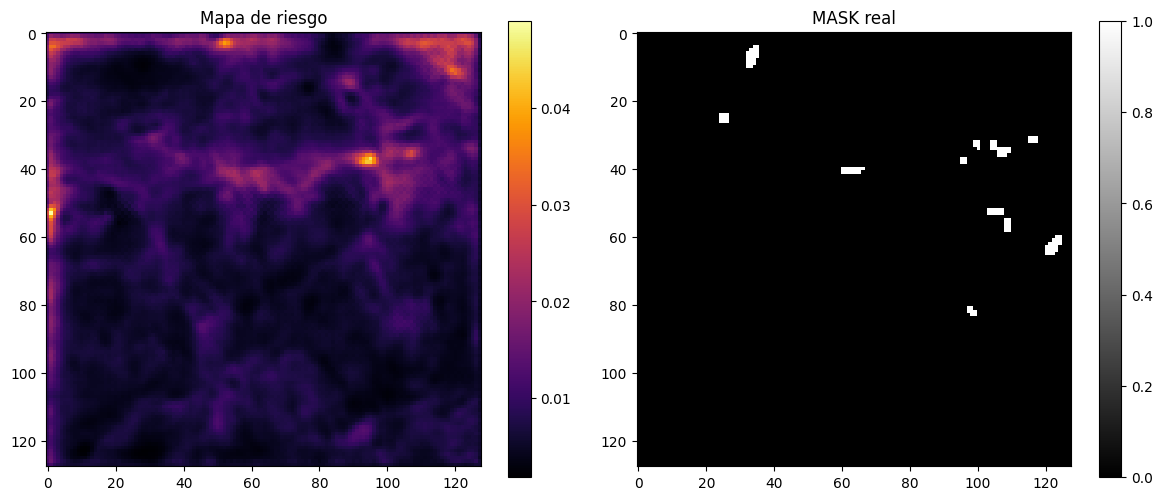

In [15]:
idx = random.randint(0, len(val_dataset)-1)

x, y = val_dataset[idx]
x = x.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    risk_map = probs[:, 1, :, :]

risk = risk_map[0].detach().cpu().numpy()
mask = y.detach().cpu().numpy()

print("Patch:", split["val"][idx])
print("Risk min/max:", risk.min(), risk.max())
print("MASK sum:", mask.sum())

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(risk, cmap="inferno")
plt.title("Mapa de riesgo")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("MASK real")
plt.colorbar()

plt.tight_layout()
plt.show()

Vamos a replicar el json para s1dsc y sen2

In [21]:
def convert_patch_id(patch_id, new_prefix):
    """
    Convierte un patch_id a otro prefijo manteniendo el número.
    
    Ej:
    italy_s1asc_255_enriched.nc → italy_s1dsc_255_enriched.nc
    """
    base = os.path.basename(patch_id)

    parts = base.split("_")
    
    # parts = ['italy', 's1asc', '255', 'enriched.nc']
    if len(parts) < 4:
        raise ValueError(f"Formato inesperado: {patch_id}")
    
    new_name = f"{parts[0]}_{new_prefix}_{parts[2]}_{parts[3]}"
    
    return new_name


def convert_split_json(
    input_json,
    output_json,
    new_prefix,
    n_jobs=4
):
    """
    Replica un split.json cambiando el prefijo de los patch_ids.
    
    Parámetros:
    ----------
    input_json : str
        Ruta al json original (s1asc)
    output_json : str
        Ruta donde guardar el nuevo json
    new_prefix : str
        's1dsc' o 's2'
    n_jobs : int
        Número de procesos paralelos
    """

    with open(input_json, "r") as f:
        split = json.load(f)

    new_split = {}

    for key in ["train", "val", "test"]:
        patch_list = split[key]

        new_list = Parallel(n_jobs=n_jobs)(
            delayed(convert_patch_id)(pid, new_prefix)
            for pid in patch_list
        )

        new_split[key] = new_list

    # Guardar nuevo json
    with open(output_json, "w") as f:
        json.dump(new_split, f, indent=2)

    print(f"✅ Nuevo split guardado en: {output_json}")

In [22]:
input_json = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split_asc.json"
output_json = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split_dsc.json"

convert_split_json(
    input_json,
    output_json,
    new_prefix = "s1dsc",
    n_jobs=4
)

✅ Nuevo split guardado en: C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split_dsc.json


In [23]:
input_json = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split_asc.json"
output_json = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split_Sen2.json"

convert_split_json(
    input_json,
    output_json,
    new_prefix = "s2",
    n_jobs=4
)

✅ Nuevo split guardado en: C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split_Sen2.json


Guardar las predicciones

In [ ]:
def save_predictions(
    model,
    dataset,
    split,
    device,
    output_dir
):
    """
    Guarda predicciones de un modelo para todos los patches de un dataset.
    """

    os.makedirs(output_dir, exist_ok=True)

    model.eval()

    for idx in tqdm(range(len(dataset))):

        patch_id = split[idx]

        x, y = dataset[idx]
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            risk_map = probs[:, 1, :, :]  # (1, H, W)

        risk_map = risk_map[0].cpu()  # (H, W)

        out_path = os.path.join(
            output_dir,
            patch_id.replace(".nc", "_pred.pt")
        )

        torch.save({
            "patch_id": patch_id,
            "prob": risk_map,
            "y": y  # opcional pero recomendable
        }, out_path)

    print(f"✅ Predicciones guardadas en: {output_dir}")

In [ ]:
def extract_patch_id(filename):
    """
    Extrae el número de patch.
    Ej:
    italy_s1asc_255_pred.pt -> 255
    italy_s2_255_pred.pt    -> 255
    italy_fused_255_pred.pt -> 255
    """
    match = re.search(r"_(\d+)_", filename)
    if match is None:
        raise ValueError(f"No se pudo extraer ID de patch: {filename}")
    return match.group(1)


def build_index(pred_dir):
    """
    Crea índice {patch_id: filename}
    """
    files = [f for f in os.listdir(pred_dir) if f.endswith(".pt")]
    return {extract_patch_id(f): f for f in files}


def load_prob_item(path):
    """
    Carga una predicción.
    Acepta archivos con clave 'prob' o 'prob_final'.
    """
    item = torch.load(path, map_location="cpu")

    if "prob_final" in item:
        prob = item["prob_final"].float()
    elif "prob" in item:
        prob = item["prob"].float()
    else:
        raise KeyError(f"No existe 'prob' ni 'prob_final' en {path}")

    y = item.get("y", None)
    if y is not None:
        y = y.long()

    patch_id = item.get("patch_id", None)

    return prob, y, patch_id


def get_predictions(
    pred_dirs,
    weights=None,
    output_dir=None,
    threshold=0.5,
    return_metrics=True
):
    """
    Función general para predicciones individuales o fusionadas.

    Parámetros
    ----------
    pred_dirs : str o list[str]
        Una carpeta para un modelo solo, o varias carpetas para fusión.
        Ej:
        pred_dirs="/content/pred_s2_val"
        pred_dirs=["/content/pred_s1asc_val", "/content/pred_s1dsc_val"]

    weights : list[float] o None
        Pesos de fusión. Si None, media simple.

    output_dir : str o None
        Si se indica, guarda las predicciones fusionadas/normalizadas.

    threshold : float
        Umbral para convertir probabilidad en máscara binaria.

    return_metrics : bool
        Si True, calcula métricas si existe y.

    Devuelve
    --------
    results : dict
        {
            patch_id: {
                "prob_final": tensor(H,W),
                "y": tensor(H,W) or None,
                "pred": tensor(H,W)
            }
        }

    metrics : dict o None
    """

    if isinstance(pred_dirs, str):
        pred_dirs = [pred_dirs]

    n_models = len(pred_dirs)

    if weights is None:
        weights = [1.0 / n_models] * n_models
    else:
        assert len(weights) == n_models, "weights debe tener la misma longitud que pred_dirs"
        s = sum(weights)
        weights = [w / s for w in weights]

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)

    indices = [build_index(d) for d in pred_dirs]

    common_ids = set(indices[0].keys())
    for idx in indices[1:]:
        common_ids &= set(idx.keys())

    common_ids = sorted(common_ids, key=lambda x: int(x))

    results = {}

    tp = fp = fn = tn = 0

    for patch_num in tqdm(common_ids):

        probs = []
        y_ref = None

        for d, index, w in zip(pred_dirs, indices, weights):
            file = index[patch_num]
            path = os.path.join(d, file)

            prob, y, patch_id = load_prob_item(path)
            probs.append(w * prob)

            if y_ref is None and y is not None:
                y_ref = y

        prob_final = torch.stack(probs, dim=0).sum(dim=0)
        pred = (prob_final >= threshold).long()

        results[patch_num] = {
            "prob_final": prob_final,
            "y": y_ref,
            "pred": pred
        }

        if output_dir is not None:
            out_path = os.path.join(output_dir, f"patch_{patch_num}_pred.pt")
            torch.save({
                "patch_id": patch_num,
                "prob_final": prob_final,
                "y": y_ref,
                "pred": pred,
                "weights": weights,
                "source_dirs": pred_dirs
            }, out_path)

        if return_metrics and y_ref is not None:
            y_ref = y_ref.long()

            tp += ((pred == 1) & (y_ref == 1)).sum().item()
            fp += ((pred == 1) & (y_ref == 0)).sum().item()
            fn += ((pred == 0) & (y_ref == 1)).sum().item()
            tn += ((pred == 0) & (y_ref == 0)).sum().item()

    metrics = None

    if return_metrics:
        eps = 1e-8

        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        iou = tp / (tp + fp + fn + eps)
        accuracy = (tp + tn) / (tp + tn + fp + fn + eps)

        metrics = {
            "threshold": threshold,
            "n_patches": len(common_ids),
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "iou": iou,
            "accuracy": accuracy
        }

    return results, metrics

In [ ]:
results_s2, metrics_s2 = get_predictions(
    pred_dirs="/content/drive/MyDrive/pred_sen2_val/pred_sen2_val",
    threshold=0.1
)

print(metrics_s2)

In [ ]:
import os
import random
import torch
from tqdm import tqdm


def pt_name(patch_id):
    return patch_id.replace(".nc", ".pt")


def positive_ratio(y):
    return (y == 1).float().mean().item()


def find_positive_crop_candidates(
    pt_dir,
    patch_ids,
    crop_size=32,
    min_crop_ratio=0.25,
    stride=8
):
    candidates = []

    for patch_id in tqdm(patch_ids, desc="Buscando crops positivos"):
        path = os.path.join(pt_dir, pt_name(patch_id))
        item = torch.load(path, map_location="cpu")
        y = item["y"].long()

        H, W = y.shape

        for r in range(0, H - crop_size + 1, stride):
            for c in range(0, W - crop_size + 1, stride):
                crop_y = y[r:r+crop_size, c:c+crop_size]
                ratio = positive_ratio(crop_y)

                if ratio >= min_crop_ratio:
                    candidates.append({
                        "patch_id": patch_id,
                        "r": r,
                        "c": c,
                        "ratio": ratio
                    })

    print(f"Crops positivos encontrados: {len(candidates)}")
    return candidates

In [ ]:
def make_frankenstein_patch(
    pt_dir,
    target_patch_id,
    crop_candidates,
    crop_size=32,
    target_patch_ratio=0.20,
    max_pastes=12,
    max_attempts=50
):
    target_path = os.path.join(pt_dir, pt_name(target_patch_id))
    target_item = torch.load(target_path, map_location="cpu")

    x_new = target_item["x"].clone()
    y_new = target_item["y"].clone().long()

    H, W = y_new.shape

    pastes = 0
    attempts = 0

    while positive_ratio(y_new) < target_patch_ratio and pastes < max_pastes and attempts < max_attempts:
        attempts += 1

        crop_info = random.choice(crop_candidates)

        source_path = os.path.join(pt_dir, pt_name(crop_info["patch_id"]))
        source_item = torch.load(source_path, map_location="cpu")

        x_src = source_item["x"]
        y_src = source_item["y"].long()

        sr = crop_info["r"]
        sc = crop_info["c"]

        crop_x = x_src[:, :, sr:sr+crop_size, sc:sc+crop_size]
        crop_y = y_src[sr:sr+crop_size, sc:sc+crop_size]

        # Buscar zona destino preferiblemente negativa
        dr = random.randint(0, H - crop_size)
        dc = random.randint(0, W - crop_size)

        target_area = y_new[dr:dr+crop_size, dc:dc+crop_size]

        # Evitar pegar encima de muchos positivos ya existentes
        if positive_ratio(target_area) > 0.05:
            continue

        # Copiar x e y juntos
        x_new[:, :, dr:dr+crop_size, dc:dc+crop_size] = crop_x
        y_new[dr:dr+crop_size, dc:dc+crop_size] = crop_y

        pastes += 1

    return {
        "x": x_new,
        "y": y_new,
        "source_target": target_patch_id,
        "positive_ratio": positive_ratio(y_new),
        "n_pastes": pastes
    }

In [ ]:
def create_frankenstein_dataset(
    pt_dir,
    train_ids,
    output_dir,
    increase_fraction=0.5,
    crop_size=32,
    min_crop_ratio=0.25,
    target_patch_ratio=0.20,
    max_pastes=12,
    seed=42
):
    random.seed(seed)
    os.makedirs(output_dir, exist_ok=True)

    crop_candidates = find_positive_crop_candidates(
        pt_dir=pt_dir,
        patch_ids=train_ids,
        crop_size=crop_size,
        min_crop_ratio=min_crop_ratio,
        stride=8
    )

    positive_train_ids = []

    for patch_id in train_ids:
        item = torch.load(os.path.join(pt_dir, pt_name(patch_id)), map_location="cpu")
        if item["y"].sum() > 0:
            positive_train_ids.append(patch_id)

    n_new = int(len(train_ids) * increase_fraction)

    print(f"Patches train originales: {len(train_ids)}")
    print(f"Patches positivos disponibles: {len(positive_train_ids)}")
    print(f"Nuevos patches Frankenstein: {n_new}")

    new_patch_ids = []

    for i in tqdm(range(n_new), desc="Creando Frankenstein patches"):
        target_patch_id = random.choice(positive_train_ids)

        new_item = make_frankenstein_patch(
            pt_dir=pt_dir,
            target_patch_id=target_patch_id,
            crop_candidates=crop_candidates,
            crop_size=crop_size,
            target_patch_ratio=target_patch_ratio,
            max_pastes=max_pastes
        )

        new_name = f"frankenstein_{i:06d}.pt"
        out_path = os.path.join(output_dir, new_name)

        torch.save(new_item, out_path)
        new_patch_ids.append(new_name)

    return new_patch_ids

In [40]:
ds = xr.open_dataset(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\temp\italy_s2_255_enriched.nc")

In [43]:
ds.close()

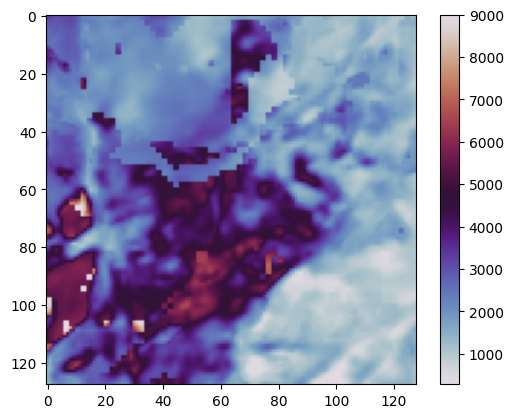

In [41]:
prec7 = ds['B05'].isel(time = 5)
plt.imshow(prec7, cmap='twilight')
plt.colorbar()
plt.show()

In [30]:
ds = xr.open_dataset(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Bandas_imputadas\Sen2\italy_s2_255_enriched.nc")


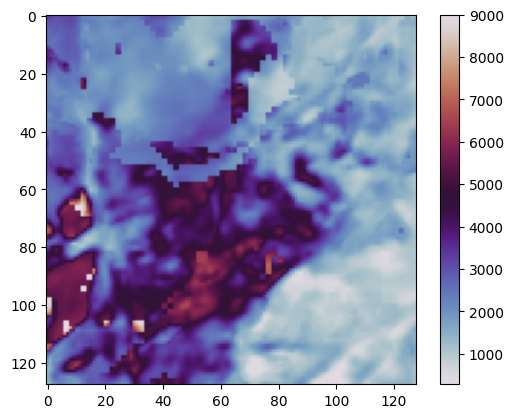

In [32]:
prec7 = ds['B05'].isel(time = 5)
plt.imshow(prec7, cmap='twilight')
plt.colorbar()
plt.show()

In [33]:
ds = xr.open_dataset(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Bandas_sin_imputar\Sen2\italy_s2_255_enriched.nc")

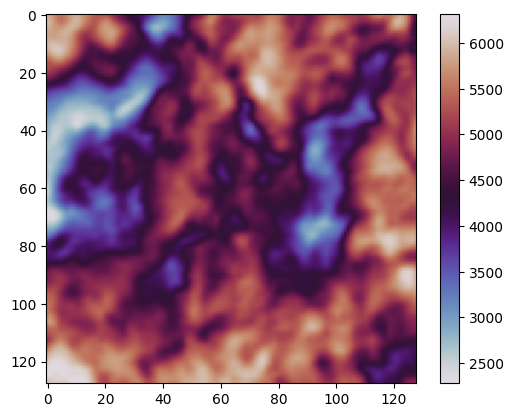

In [34]:
prec7 = ds['B05'].isel(time = 5)
plt.imshow(prec7, cmap='twilight')
plt.colorbar()
plt.show()

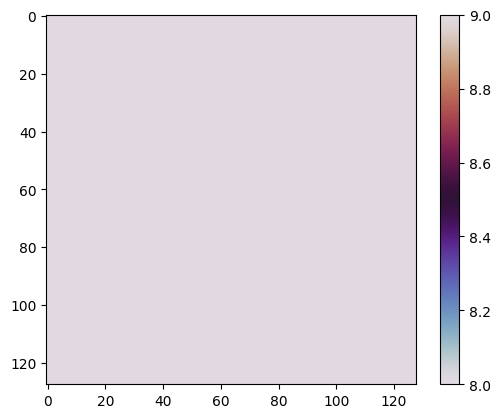

In [42]:
prec7 = ds['SCL'].isel(time = 5)
plt.imshow(prec7, cmap='twilight')
plt.colorbar()
plt.show()

GRAFICAMOS LA DISTRIBUCIÓN DE PROPORCIÓN DE PÍXELES POSITIVOS EN PATCHES

In [3]:
output_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Procesamiento\split_asc.json"
with open(output_path, "r", encoding="utf-8") as f:
    split = json.load(f)

100%|██████████| 835/835 [00:15<00:00, 54.91it/s]


Número de patches con deslizamiento: 481
Ratio medio: 0.00973479019133316
Mediana: 0.00439453125
Máximo: 0.1180419921875
Mínimo: 0.000244140625


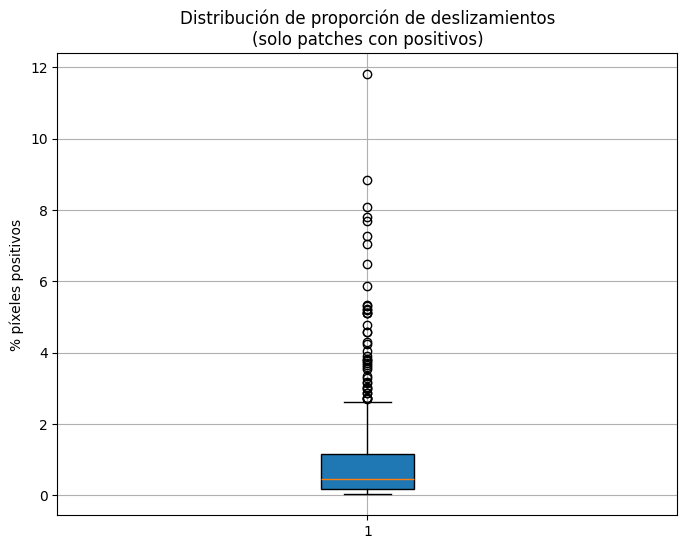

In [4]:
# -----------------------------
# CONFIG
# -----------------------------

pt_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\Enriched_files_pt\asc"  # tu carpeta .pt
patch_ids = split["train"] + split["val"] + split["test"]

# -----------------------------
# CALCULAR RATIOS
# -----------------------------

positive_ratios = []

for patch_id in tqdm(patch_ids):

    path = os.path.join(
        pt_dir,
        patch_id.replace(".nc", ".pt")
    )

    item = torch.load(path, map_location="cpu")

    y = item["y"].long()

    positives = (y == 1).sum().item()

    # ignorar patches sin deslizamiento
    if positives == 0:
        continue

    ratio = positives / y.numel()

    positive_ratios.append(ratio)

# -----------------------------
# ESTADÍSTICAS
# -----------------------------

positive_ratios = np.array(positive_ratios)

print("Número de patches con deslizamiento:", len(positive_ratios))
print("Ratio medio:", positive_ratios.mean())
print("Mediana:", np.median(positive_ratios))
print("Máximo:", positive_ratios.max())
print("Mínimo:", positive_ratios.min())

# -----------------------------
# BOXPLOT
# -----------------------------

plt.figure(figsize=(8,6))

plt.boxplot(
    positive_ratios * 100,
    vert=True,
    patch_artist=True
)

plt.ylabel("% píxeles positivos")
plt.title("Distribución de proporción de deslizamientos\n(solo patches con positivos)")

plt.grid(True)

plt.show()

AÑADIREMOS PATCHES CON MÍNIMO PROPORCIÓN DEL 2%